# RedRock Email Classification — Data Exploration & Feature Engineering

This notebook covers ingestion, exploratory data analysis, and feature engineering for the RedRock email classification take-home challenge.

Pipeline stage: **Ingestion → EDA → Preprocessing / Feature Engineering** (modelling happens in a separate notebook / `src/modelling.py`).

## 1. Setup

In [1]:
import sys
sys.path.append("..")  # go up to project root from notebooks/

import importlib
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_colwidth", 200)

BASE_DIR = Path(r"C:\Users\elias\OneDrive\Desktop\izasi.ai\Email classifier")
TRAIN_DIR = BASE_DIR / "train"
TEST_DIR = BASE_DIR / "test"
LABELS_PATH = BASE_DIR / "train_labels.csv"

print(TRAIN_DIR.exists(), TEST_DIR.exists(), LABELS_PATH.exists())

True True True


## 2. Ingestion

Reload the `src` modules to make sure the latest version of `ingestion.py`, `preprocessing.py`, and `features.py` is used (important after editing the `.py` files without restarting the kernel).

In [2]:
import importlib
import src.features
importlib.reload(src.features)
print([name for name in dir(src.features) if not name.startswith("_")])


['DEPARTMENT_KEYWORDS', 'INTERNAL_DOMAIN', 'add_engineered_features', 'count_question_marks', 'extract_greeting_target', 'extract_sender_domain', 'has_dollar_amount', 'is_department_greeting', 'is_internal_sender', 'is_internal_signature', 'pd', 're']


In [3]:
import shutil
shutil.rmtree("../src/__pycache__", ignore_errors=True)

In [4]:
import src.features
print(src.features.__file__)

c:\Users\elias\OneDrive\Desktop\izasi.ai\Email classifier\notebooks\..\src\features.py


In [5]:
import shutil
shutil.rmtree("../src/__pycache__", ignore_errors=True)
print("Cache supprimé")

Cache supprimé


In [6]:
import sys
sys.path.append("..")

import src.features
print(src.features.__file__)
print([name for name in dir(src.features) if not name.startswith("_")])

c:\Users\elias\OneDrive\Desktop\izasi.ai\Email classifier\notebooks\..\src\features.py
['DEPARTMENT_KEYWORDS', 'INTERNAL_DOMAIN', 'add_engineered_features', 'count_question_marks', 'extract_greeting_target', 'extract_sender_domain', 'has_dollar_amount', 'is_department_greeting', 'is_internal_sender', 'is_internal_signature', 'pd', 're']


In [7]:
import src.ingestion, src.preprocessing, src.features
importlib.reload(src.ingestion)
importlib.reload(src.preprocessing)
importlib.reload(src.features)
importlib.reload(src.features)
from src.ingestion import build_dataframe, load_labels
from src.preprocessing import add_clean_text_column
from src.features import add_engineered_features

train_df = build_dataframe(TRAIN_DIR)
test_df = build_dataframe(TEST_DIR)
labels_df = load_labels(LABELS_PATH)

print("train_df:", train_df.shape)
print("test_df:", test_df.shape)
print("labels_df:", labels_df.shape)
print("\nColumns in train_df:", train_df.columns.tolist())
train_df.head()

train_df: (44, 9)
test_df: (12, 9)
labels_df: (44, 2)

Columns in train_df: ['email_id', 'subject', 'sender', 'date_received', 'greeting', 'message', 'signature', 'body', 'source_filename']


,email_id,subject,sender,date_received,greeting,message,signature,body,source_filename
0,31,Account Transfer Request,cjones@gmail.com,2025-04-15,"Dear Account Services,",I would like to transfer my account to another financial institution. What is the process and any associated fees?,Anthony Scott,"Dear Account Services, I would like to transfer my account to another financial institution. What is the process and any associated fees? Anthony Scott",email_1.html
1,20,Job Application Response,security@redrock.com,2025-03-18,"Dear Applicant,",Thank you for your interest in the Financial Analyst position. We have received your application and will review it carefully.,RedRock HR Department,"Dear Applicant, Thank you for your interest in the Financial Analyst position. We have received your application and will review it carefully. RedRock HR Department",email_10.html
2,10,System Maintenance Notice,jamesg@gmail.com,2025-08-12,"Dear Clients,",We will be performing scheduled system maintenance this weekend. Online banking services may be temporarily unavailable.,RedRock IT Department,"Dear Clients, We will be performing scheduled system maintenance this weekend. Online banking services may be temporarily unavailable. RedRock IT Department",email_11.html
3,34,Pet Insurance Claim,daniel.r@gmail.com,2025-01-30,"Dear Pet Insurance Claims,","I need to file a claim for my dog's emergency surgery. The total cost was $3,200 and the procedure was performed on February 14th.",Heather Carter,"Dear Pet Insurance Claims, I need to file a claim for my dog's emergency surgery. The total cost was $3,200 and the procedure was performed on February 14th. Heather Carter",email_12.html
4,42,Asset Allocation Review,johnsmith1985@gmail.com,2025-05-14,"Dear Investment Advisor,",I would like to review my current asset allocation and discuss whether it aligns with my long-term financial goals and risk tolerance.,Rebecca Taylor,"Dear Investment Advisor, I would like to review my current asset allocation and discuss whether it aligns with my long-term financial goals and risk tolerance. Rebecca Taylor",email_13.html


In [8]:
# Sanity check: greeting / message / signature should NOT be all-missing.
# If they are, src/ingestion.py on disk does not yet contain the
# paragraph-splitting version of parse_email_html().
print("Missing greeting/message/signature (train):",
      train_df[["greeting", "message", "signature"]].isna().sum().to_dict())
print("Missing greeting/message/signature (test):",
      test_df[["greeting", "message", "signature"]].isna().sum().to_dict())

Missing greeting/message/signature (train): {'greeting': 0, 'message': 0, 'signature': 0}
Missing greeting/message/signature (test): {'greeting': 0, 'message': 0, 'signature': 0}


## 3. Join with ground-truth labels

**Important**: the join key here is `source_filename` ↔ `filename`, which is valid *only* because both come from the same `train/` folder. Filenames are NOT reliable identifiers across `train/` and `test/` (see verification below) — the true identifier is `email_id`, extracted from each email's `data-field="email_id"` metadata.

In [9]:
train_labeled = train_df.merge(
    labels_df, left_on="source_filename", right_on="filename", how="left"
)

print("Emails without a label after join:", train_labeled["true_category"].isna().sum())
train_labeled.head()

Emails without a label after join: 0


,email_id,subject,sender,date_received,greeting,message,signature,body,source_filename,filename,true_category
0,31,Account Transfer Request,cjones@gmail.com,2025-04-15,"Dear Account Services,",I would like to transfer my account to another financial institution. What is the process and any associated fees?,Anthony Scott,"Dear Account Services, I would like to transfer my account to another financial institution. What is the process and any associated fees? Anthony Scott",email_1.html,email_1.html,Account Management
1,20,Job Application Response,security@redrock.com,2025-03-18,"Dear Applicant,",Thank you for your interest in the Financial Analyst position. We have received your application and will review it carefully.,RedRock HR Department,"Dear Applicant, Thank you for your interest in the Financial Analyst position. We have received your application and will review it carefully. RedRock HR Department",email_10.html,email_10.html,Other
2,10,System Maintenance Notice,jamesg@gmail.com,2025-08-12,"Dear Clients,",We will be performing scheduled system maintenance this weekend. Online banking services may be temporarily unavailable.,RedRock IT Department,"Dear Clients, We will be performing scheduled system maintenance this weekend. Online banking services may be temporarily unavailable. RedRock IT Department",email_11.html,email_11.html,Other
3,34,Pet Insurance Claim,daniel.r@gmail.com,2025-01-30,"Dear Pet Insurance Claims,","I need to file a claim for my dog's emergency surgery. The total cost was $3,200 and the procedure was performed on February 14th.",Heather Carter,"Dear Pet Insurance Claims, I need to file a claim for my dog's emergency surgery. The total cost was $3,200 and the procedure was performed on February 14th. Heather Carter",email_12.html,email_12.html,Insurance Claims
4,42,Asset Allocation Review,johnsmith1985@gmail.com,2025-05-14,"Dear Investment Advisor,",I would like to review my current asset allocation and discuss whether it aligns with my long-term financial goals and risk tolerance.,Rebecca Taylor,"Dear Investment Advisor, I would like to review my current asset allocation and discuss whether it aligns with my long-term financial goals and risk tolerance. Rebecca Taylor",email_13.html,email_13.html,Investment Advisory


## 4. Exploratory Data Analysis

### 4.1 Class distribution

In [10]:
class_counts = train_labeled["true_category"].value_counts()
print(class_counts)
print("\nProportions (%):")
print((class_counts / len(train_labeled) * 100).round(1))

true_category
Account Management     13
Investment Advisory    12
Insurance Claims        7
Other                   6
Loan Processing         6
Name: count, dtype: int64

Proportions (%):
true_category
Account Management     29.5
Investment Advisory    27.3
Insurance Claims       15.9
Other                  13.6
Loan Processing        13.6
Name: count, dtype: float64


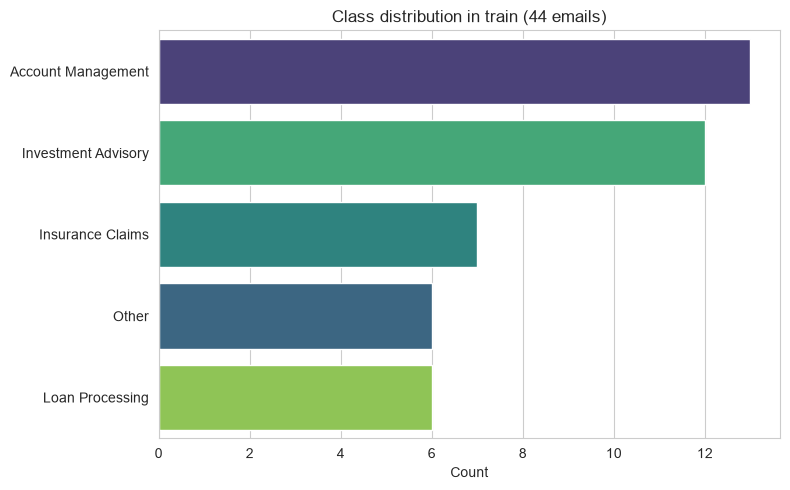

In [11]:
fig, ax = plt.subplots()
order = train_labeled["true_category"].value_counts().index
sns.countplot(data=train_labeled, y="true_category", order=order, hue="true_category",
              legend=False, palette="viridis", ax=ax)
ax.set_title("Class distribution in train (44 emails)")
ax.set_xlabel("Count")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

### 4.2 Text length

In [12]:
train_labeled["text_length_words"] = (
    train_labeled["subject"].fillna("") + " " + train_labeled["body"].fillna("")
).str.split().apply(len)

print(train_labeled["text_length_words"].describe())
print("\nAverage length by category:")
print(train_labeled.groupby("true_category")["text_length_words"].mean().round(1))

count    44.000000
mean     27.409091
std       2.679102
min      22.000000
25%      25.000000
50%      27.500000
75%      29.000000
max      35.000000
Name: text_length_words, dtype: float64

Average length by category:
true_category
Account Management     26.5
Insurance Claims       30.3
Investment Advisory    26.2
Loan Processing        29.0
Other                  26.8
Name: text_length_words, dtype: float64


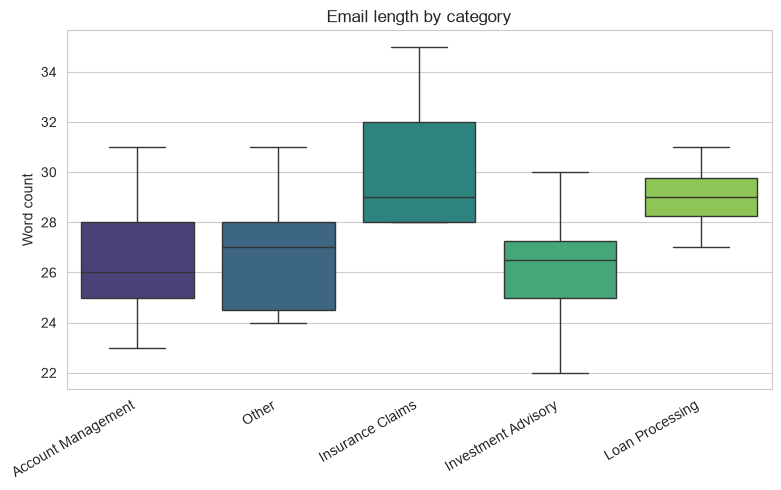

In [13]:
fig, ax = plt.subplots()
sns.boxplot(data=train_labeled, x="true_category", y="text_length_words",
            hue="true_category", legend=False, palette="viridis", ax=ax)
ax.set_title("Email length by category")
ax.set_xlabel("")
ax.set_ylabel("Word count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### 4.3 Missing values

In [14]:
print("Train:")
print(train_labeled[["subject", "sender", "date_received", "greeting", "message",
                      "signature", "true_category"]].isna().sum())

print("\nTest:")
print(test_df[["subject", "sender", "date_received", "greeting", "message",
               "signature"]].isna().sum())

Train:
subject          0
sender           0
date_received    0
greeting         0
message          0
signature        0
true_category    0
dtype: int64

Test:
subject          0
sender           0
date_received    0
greeting         0
message          0
signature        0
dtype: int64


### 4.4 Train/test leakage check

Filenames (`email_1.html`, etc.) are numbered independently within each folder and do NOT correspond to the same underlying email across `train/` and `test/`. The check below verifies there is no real overlap, using the internal `email_id` and exact body content.

In [15]:
train_internal_ids = set(train_df["email_id"])
test_internal_ids = set(test_df["email_id"])
overlap_internal = train_internal_ids & test_internal_ids
print(f"Internal email_id overlap between train and test: {len(overlap_internal)}")

train_body_set = set(train_df["body"].dropna())
test_body_set = set(test_df["body"].dropna())
overlap_body = train_body_set & test_body_set
print(f"Identical email bodies between train and test: {len(overlap_body)}")

print("\nExample — same filename, different internal email_id:")
print(train_df[train_df["source_filename"] == "email_1.html"][["source_filename", "email_id"]])
print(test_df[test_df["source_filename"] == "email_1.html"][["source_filename", "email_id"]])

print("\nDuplicate email_id — train:", train_df["email_id"].duplicated().sum())
print("Duplicate email_id — test:", test_df["email_id"].duplicated().sum())

Internal email_id overlap between train and test: 0
Identical email bodies between train and test: 0

Example — same filename, different internal email_id:
  source_filename email_id
0    email_1.html       31
  source_filename email_id
0    email_1.html       35

Duplicate email_id — train: 0
Duplicate email_id — test: 0


### 4.5 Near-duplicate detection (TF-IDF cosine similarity)

In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

texts = train_labeled["subject"].fillna("") + ". " + train_labeled["body"].fillna("")
vec = TfidfVectorizer(stop_words="english")
tfidf_matrix = vec.fit_transform(texts)
sim_matrix = cosine_similarity(tfidf_matrix)
np.fill_diagonal(sim_matrix, 0)

threshold = 0.85
pairs = np.argwhere(sim_matrix > threshold)
print(f"Near-duplicate pairs (similarity > {threshold}):", len(pairs) // 2)

for i, j in pairs:
    if i < j:
        print(f"\nSimilarity {sim_matrix[i, j]:.3f} between email_id "
              f"{train_labeled.iloc[i]['email_id']} and {train_labeled.iloc[j]['email_id']}")
        print(f"  [{train_labeled.iloc[i]['true_category']}] {train_labeled.iloc[i]['subject']}")
        print(f"  [{train_labeled.iloc[j]['true_category']}] {train_labeled.iloc[j]['subject']}")

Near-duplicate pairs (similarity > 0.85): 0


### 4.6 Sender / date sanity checks

In [17]:
import re

email_pattern = re.compile(r"^[^@\s]+@[^@\s]+\.[^@\s]+$")
train_bad_sender = ~train_df["sender"].fillna("").apply(lambda s: bool(email_pattern.match(s)))
test_bad_sender = ~test_df["sender"].fillna("").apply(lambda s: bool(email_pattern.match(s)))
print("Malformed sender (train):", train_bad_sender.sum())
print("Malformed sender (test):", test_bad_sender.sum())

train_bad_date = pd.to_datetime(train_df["date_received"], errors="coerce").isna()
test_bad_date = pd.to_datetime(test_df["date_received"], errors="coerce").isna()
print("\nUnparseable dates (train):", train_bad_date.sum())
print("Unparseable dates (test):", test_bad_date.sum())
print("\nTrain date range:", pd.to_datetime(train_df["date_received"], errors="coerce").min(),
      "→", pd.to_datetime(train_df["date_received"], errors="coerce").max())
print("Test date range:", pd.to_datetime(test_df["date_received"], errors="coerce").min(),
      "→", pd.to_datetime(test_df["date_received"], errors="coerce").max())

Malformed sender (train): 0
Malformed sender (test): 0

Unparseable dates (train): 0
Unparseable dates (test): 0

Train date range: 2025-01-13 00:00:00 → 2025-08-28 00:00:00
Test date range: 2025-01-05 00:00:00 → 2025-08-31 00:00:00


## 5. Preprocessing & Feature Engineering

`add_clean_text_column` builds the `clean_text` field used for TF-IDF (subject + message, excluding the near-unique signature and the raw greeting). `add_engineered_features` adds the structured candidate features (see `src/features.py` docstring for the rationale behind each one).

In [18]:
train_labeled = add_clean_text_column(train_labeled)
train_labeled = add_engineered_features(train_labeled)
test_df = add_clean_text_column(test_df)
test_df = add_engineered_features(test_df)

train_labeled[["email_id", "clean_text", "is_internal_sender", "is_internal_signature",
               "greeting_target", "is_department_greeting", "has_dollar_amount",
               "question_mark_count", "true_category"]].head(10)

,email_id,clean_text,is_internal_sender,is_internal_signature,greeting_target,is_department_greeting,has_dollar_amount,question_mark_count,true_category
0,31,Account Transfer Request. I would like to transfer my account to another financial institution. What is the process and any associated fees?,False,False,Account Services,True,False,1,Account Management
1,20,Job Application Response. Thank you for your interest in the Financial Analyst position. We have received your application and will review it carefully.,True,True,Applicant,False,False,0,Other
2,10,System Maintenance Notice. We will be performing scheduled system maintenance this weekend. Online banking services may be temporarily unavailable.,False,True,Clients,False,False,0,Other
3,34,"Pet Insurance Claim. I need to file a claim for my dog's emergency surgery. The total cost was $3,200 and the procedure was performed on February 14th.",False,False,Pet Insurance Claims,False,True,0,Insurance Claims
4,42,Asset Allocation Review. I would like to review my current asset allocation and discuss whether it aligns with my long-term financial goals and risk tolerance.,False,False,Investment Advisor,True,False,0,Investment Advisory
5,45,Account Verification Request. I need a letter verifying my account balance and relationship with RedRock for a loan application with another institution.,True,False,Verification Department,True,False,0,Account Management
6,30,Security Alert. We detected unusual activity on your account. Please verify your recent transactions and contact us if you notice any unauthorized activity.,False,True,Client,False,False,0,Other
7,56,Investment Goal Review. I would like to review my investment goals and create a plan to achieve them within my timeline.,True,False,Financial Planner,True,False,0,Investment Advisory
8,4,"Insurance Claim Submission. I need to file a claim for my recent car accident. The incident occurred on January 10th, 2025. Please find the police report attached.",False,False,NaN,False,False,0,Insurance Claims
9,22,"ESG Investment Options. I am interested in learning about your ESG (Environmental, Social, Governance) investment options and how they align with my values.",False,False,NaN,False,False,0,Investment Advisory


### 5.1 Empirical validation of candidate features

Each engineered feature is only kept in the final modelling pipeline if it shows a real difference across categories here. Features that don't should be documented as “tested, not retained” rather than silently dropped or kept on intuition alone.

In [19]:
for feat in ["is_internal_sender", "is_internal_signature", "is_department_greeting"]:
    print(f"\n--- {feat} by category (mean = share of True) ---")
    print(train_labeled.groupby("true_category")[feat].mean().round(2))

print("\n--- has_dollar_amount by category ---")
print(train_labeled.groupby("true_category")["has_dollar_amount"].mean().round(2))

print("\n--- question_mark_count by category (average) ---")
print(train_labeled.groupby("true_category")["question_mark_count"].mean().round(2))


--- is_internal_sender by category (mean = share of True) ---
true_category
Account Management     0.15
Insurance Claims       0.00
Investment Advisory    0.17
Loan Processing        0.33
Other                  0.17
Name: is_internal_sender, dtype: float64

--- is_internal_signature by category (mean = share of True) ---
true_category
Account Management     0.0
Insurance Claims       0.0
Investment Advisory    0.0
Loan Processing        0.0
Other                  1.0
Name: is_internal_signature, dtype: float64

--- is_department_greeting by category (mean = share of True) ---
true_category
Account Management     0.62
Insurance Claims       0.57
Investment Advisory    0.83
Loan Processing        0.67
Other                  0.00
Name: is_department_greeting, dtype: float64

--- has_dollar_amount by category ---
true_category
Account Management     0.08
Insurance Claims       0.14
Investment Advisory    0.00
Loan Processing        0.00
Other                  0.00
Name: has_dollar_amount,

## 6. Export a human-readable CSV (for manual review)

In [20]:
train_export_cols = ["email_id", "subject", "sender", "date_received", "greeting",
                     "message", "signature", "true_category"]
test_export_cols = ["email_id", "subject", "sender", "date_received", "greeting",
                    "message", "signature"]

(BASE_DIR / "outputs").mkdir(exist_ok=True)

train_labeled[train_export_cols].to_csv(
    BASE_DIR / "outputs" / "train_emails_readable.csv", index=False, encoding="utf-8-sig"
)
test_df[test_export_cols].to_csv(
    BASE_DIR / "outputs" / "test_emails_readable.csv", index=False, encoding="utf-8-sig"
)

print("Exported to outputs/")

Exported to outputs/
